In [49]:
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score


In [50]:
df = pd.read_csv('insurance.csv')

In [51]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [52]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [53]:
x = df.drop(columns = 'charges')
y = df['charges']

In [54]:
num_cols = x.select_dtypes(include='number').columns
obj_cols = x.select_dtypes(include='object').columns

<Axes: >

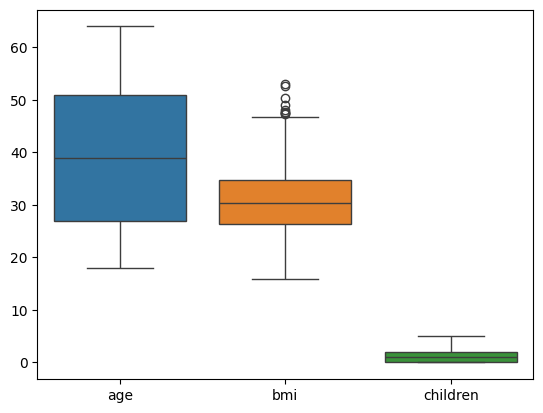

In [55]:
sns.boxplot(x[num_cols])

In [56]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y, train_size=0.8, random_state=42)

In [57]:
scaling = StandardScaler()
xtrain[num_cols] = scaling.fit_transform(xtrain[num_cols])
xtrain

,age,sex,bmi,children,smoker,region
560,0.472227,female,-1.756525,0.734336,no,northwest
1285,0.543313,female,-1.033082,-0.911192,no,northeast
1142,0.898745,female,-0.943687,-0.911192,no,southeast
969,-0.025379,female,0.622393,3.202629,no,southeast
486,1.040918,female,-1.504893,1.557100,no,northwest
...,...,...,...,...,...,...
1095,-1.518194,female,0.130717,2.379865,no,northeast
1130,-0.025379,female,-1.107579,3.202629,no,southeast
1294,1.325264,male,-0.891539,-0.911192,no,northeast
860,-0.167551,female,2.820864,0.734336,yes,southwest


In [58]:
df.select_dtypes(include='number').corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [59]:
xtrain[obj_cols].nunique()

sex       2
smoker    2
region    4
dtype: int64

In [60]:
onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
values = onehot_encoder.fit_transform(xtrain[obj_cols])
cols = onehot_encoder.get_feature_names_out()

In [61]:
df.select_dtypes(include='object').columns

Index(['sex', 'smoker', 'region'], dtype='object')

In [62]:
xtrain[cols] = values
xtrain.drop(columns = ['sex', 'smoker', 'region'],inplace= True)
xtrain

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
560,0.472227,-1.756525,0.734336,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1285,0.543313,-1.033082,-0.911192,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1142,0.898745,-0.943687,-0.911192,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
969,-0.025379,0.622393,3.202629,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
486,1.040918,-1.504893,1.557100,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1095,-1.518194,0.130717,2.379865,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1130,-0.025379,-1.107579,3.202629,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1294,1.325264,-0.891539,-0.911192,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
860,-0.167551,2.820864,0.734336,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [63]:
xtest[num_cols] = scaling.transform(xtest[num_cols])
xtest_values = onehot_encoder.transform(xtest[obj_cols])
xtest[cols] = xtest_values
xtest.drop(columns = ['sex', 'smoker', 'region'], inplace=True)
xtest

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
764,0.401140,-0.891539,0.734336,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
887,-0.238638,-0.089461,-0.911192,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
890,1.751782,-0.608453,-0.911192,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1293,0.472227,-0.797177,1.557100,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
259,-1.447107,0.225079,-0.911192,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
109,1.680696,0.749865,-0.911192,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
575,1.325264,-0.561272,-0.911192,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
535,-0.096465,-0.419729,-0.088428,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
543,1.040918,2.789410,-0.911192,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [64]:
model = LinearRegression()
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [65]:
# Evaluation part

model.score(xtrain,ytrain)

0.7417255854683333

In [66]:
model.score(xtest,ytest)

0.7835929767120723

In [67]:
slope = model.coef_
slope

array([ 3.61497541e+03,  2.03622812e+03,  5.16890247e+02,  9.29584582e+00,
       -9.29584582e+00, -1.18255644e+04,  1.18255644e+04,  4.59585244e+02,
        8.89079180e+01, -1.98279052e+02, -3.50214110e+02])

In [68]:
intercept = model.intercept_
intercept

np.float64(20311.92813931927)

In [69]:
y_pred_train = model.predict(xtrain)
y_pred_train

array([ 7094.54007011,  8344.72998713,  9153.77419778, ...,
       11441.08519155, 37314.37460682, 11453.12102783], shape=(1070,))

In [70]:
y_pred_test = model.predict(xtest)
# y_pred_test

In [71]:
# Model errors on the train data
ytrain - y_pred_train

560      2099.298430
1285      189.941813
1142    17964.219582
969     -2531.551681
486      2387.346121
            ...     
1095     -402.121792
1130      976.539987
1294      490.040058
860      8799.136393
1126    -1238.485028
Name: charges, Length: 1070, dtype: float64

In [72]:
# Model errors on the test data
ytest - y_pred_test

764       125.517976
887     -1796.571643
890     -7527.427762
1293     -152.784951
259      6777.118343
            ...     
109      7994.031168
575       461.399102
535     -1620.436882
543     22850.136498
846     -2445.885653
Name: charges, Length: 268, dtype: float64

In [73]:
# r2 score on the train data

r2_score(ytrain,y_pred_train)

0.7417255854683333

In [74]:
# r2 score on the test data
r2_score(ytest, y_pred_test)

0.7835929767120723

In [75]:
# MAE on the train data
mean_absolute_error(ytrain,y_pred_train)

4208.234572492226

In [76]:
# RMSE on the train data
root_mean_squared_error(ytrain,y_pred_train)

6105.545160099847

In [77]:
# MAE on the test data
mean_absolute_error(ytest,y_pred_test)

4181.1944737536505

In [78]:
# RMSE on the test data
root_mean_squared_error(ytest,y_pred_test)

5796.2846592762735